In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    classification_report
)

import joblib

In [2]:
df = pd.read_csv(
    r"C:\Users\sujee\Desktop\Heart_disease prediction1\Heart_Disease_Prediction.csv"
)


# 6. Data Cleaning

Data cleaning is performed to identify possible data-quality issues before model training.

In this project, we check the dataset for missing values, duplicate records, and potential outliers in continuous numerical features.

## 6.1 Check Outliers

Outliers are observations that are unusually high or low compared with the majority of the data.

The IQR (Interquartile Range) method is used to identify potential outliers in continuous variables.

In [3]:
continuous_columns = [
    "Age",
    "BP",
    "Cholesterol",
    "Max HR",
    "ST depression"
]

In [4]:
outlier_report = []

for column in continuous_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_report.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    })

outlier_report = pd.DataFrame(outlier_report)

outlier_report

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Age,48.0,61.0,13.0,28.5,80.5,0
1,BP,120.0,140.0,20.0,90.0,170.0,9
2,Cholesterol,213.0,280.0,67.0,112.5,380.5,5
3,Max HR,133.0,166.0,33.0,83.5,215.5,1
4,ST depression,0.0,1.6,1.6,-2.4,4.0,4


Boxplot

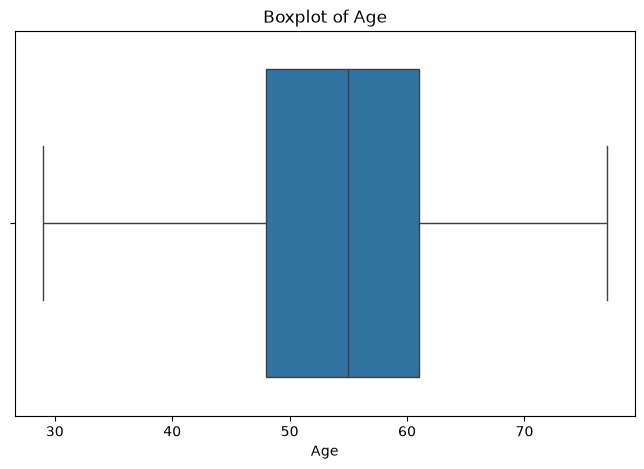

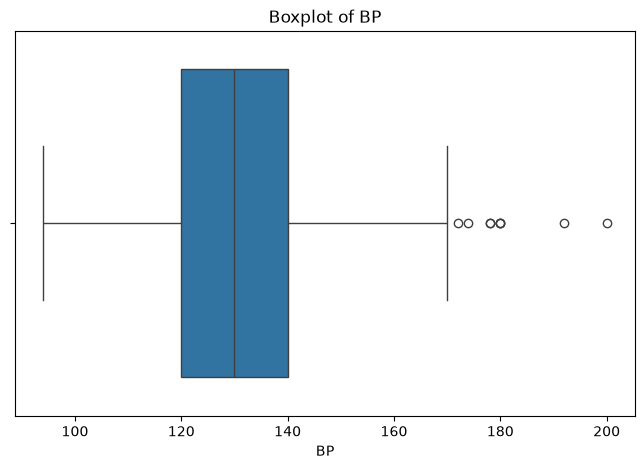

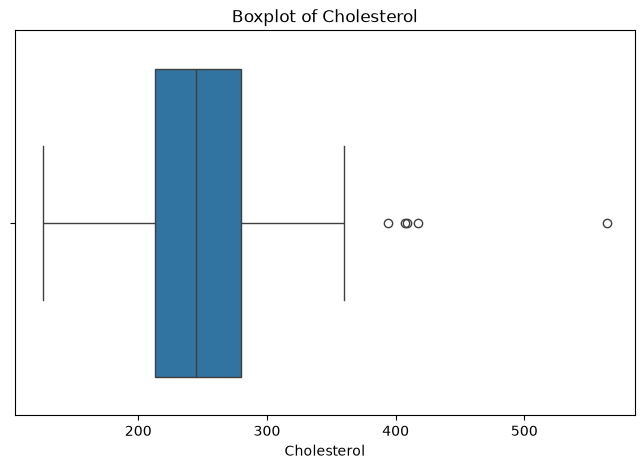

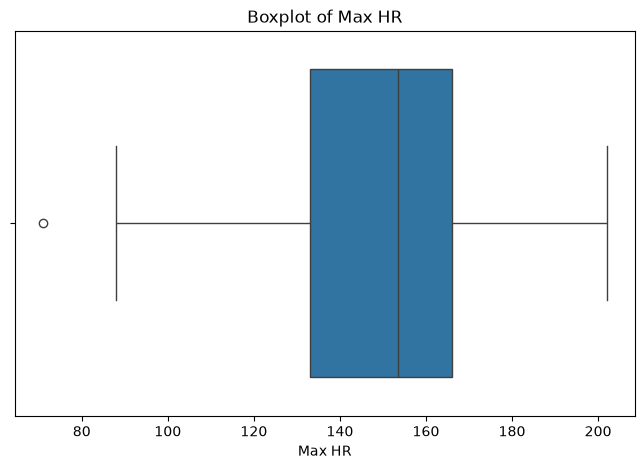

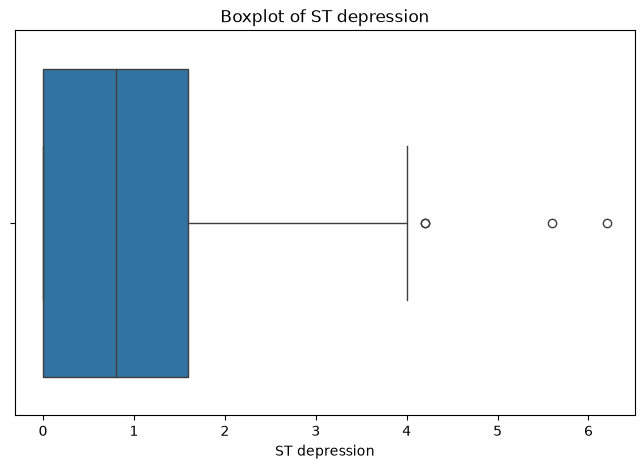

In [7]:
continuous_columns = [
    "Age",
    "BP",
    "Cholesterol",
    "Max HR",
    "ST depression"
]

for column in continuous_columns:

    plt.figure(figsize=(8,5))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")

    plt.show()

### Outlier Observation

The detected outliers are investigated using the IQR method and boxplots. Outliers are not automatically removed because they may represent genuine medical observations.